In [1]:
import os
import sys
root_dir = "/Users/livardywufianto/Projects/PatchTST"
sys.path.append(
    os.path.join(
        root_dir, 
        "PatchTST_self_supervised"
    )
)

In [2]:
import numpy as np
import pandas as pd
import os
import torch
from torch import nn

from src.models.patchTST import PatchTST
from src.learner import Learner, transfer_weights
from src.callback.core import *
from src.callback.tracking import *
from src.callback.patch_mask import *
from src.callback.transforms import *
from src.metrics import *
from src.basics import set_device
from datautils import *

/Users/livardywufianto/.pyenv/versions/3.10.13/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
args = {
    # Pretraining and Finetuning
    'is_finetune': 0,
    'is_linear_probe': 0,
    
    # Dataset and dataloader
    'dset_finetune': 'etth1', # dataset name
    'context_points': 512, # sequence length
    'target_points': 96, # forecast horizon
    'batch_size': 64, # batch size
    'num_workers': 0,
    'scaler': 'standard',
    'features': 'M', # for multivariate or Univariate
    
    # Patching (Section 1 of the model)
    'patch_len': 12, 
    'stride': 12,
    
    # RevIN (Instance Norm)
    'revin': 1, # reversible instance normalization
    
    # Model Architecture (Sections 2 & 3)
    'n_layers': 3,
    'n_heads': 16,
    'd_model': 128,
    'd_ff': 256,
    'dropout': 0.2,
    'head_dropout': 0.2,
    
    # Optimization
    'n_epochs_finetune': 20,
    'lr': 1e-4,
    
    # Tracking and Paths
    'pretrained_model': None,
    'finetuned_model_id': 1,
    'model_type': 'based_model'
}

from argparse import Namespace
args = Namespace(**args)

In [4]:
print('args:', args)

# # comment saved
# No Fine tuning plan 
# goal code exploration


# args.save_path = 'saved_models/' + args.dset_finetune + '/masked_patchtst/' + args.model_type + '/'
# if not os.path.exists(args.save_path): os.makedirs(args.save_path)

args: Namespace(is_finetune=0, is_linear_probe=0, dset_finetune='etth1', context_points=512, target_points=96, batch_size=64, num_workers=0, scaler='standard', features='M', patch_len=12, stride=12, revin=1, n_layers=3, n_heads=16, d_model=128, d_ff=256, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model=None, finetuned_model_id=1, model_type='based_model')


In [5]:
suffix_name = '_cw'+str(args.context_points)+'_tw'+str(args.target_points) + '_patch'+str(args.patch_len) + '_stride'+str(args.stride) + '_epochs-finetune' + str(args.n_epochs_finetune) + '_model' + str(args.finetuned_model_id)
if args.is_finetune: args.save_finetuned_model = args.dset_finetune+'_patchtst_finetuned'+suffix_name
elif args.is_linear_probe: args.save_finetuned_model = args.dset_finetune+'_patchtst_linear-probe'+suffix_name
else: args.save_finetuned_model = args.dset_finetune+'_patchtst_finetuned'+suffix_name

In [6]:
# # No GPU
# # get available GPU devide
# set_device()

In [7]:
def get_model(c_in, args, head_type, weight_path=None):
    """
    c_in: number of variables
    """
    # get number of patches
    num_patch = (max(args.context_points, args.patch_len)-args.patch_len) // args.stride + 1    
    print('number of patches:', num_patch)
    
    # get model
    # model = PatchTST(c_in=c_in, 
    #             target_dim=args.target_points,
    #             patch_len=args.patch_len,
    #             stride=args.stride,
    #             num_patch=num_patch,
    #             n_layers=args.n_layers,
    #             n_heads=args.n_heads,
    #             d_model=args.d_model,
    #             shared_embedding=True,
    #             d_ff=args.d_ff,                        
    #             dropout=args.dropout,
    #             head_dropout=args.head_dropout,
    #             act='relu',
    #             head_type=head_type,
    #             res_attention=False
    # )    
    model_args = {
        'c_in': c_in,
        'target_dim': args.target_points,
        'patch_len': args.patch_len,
        'stride': args.stride,
        'num_patch': num_patch,
        'n_layers': args.n_layers,
        'n_heads': args.n_heads,
        'd_model': args.d_model,
        'shared_embedding': True,
        'd_ff': args.d_ff,
        'dropout': args.dropout,
        'head_dropout': args.head_dropout,
        'act': 'relu',
        'head_type': head_type,
        'res_attention': False
    }    

    for key, value in model_args.items():
        print(f"{key}: {value}")
    model = PatchTST(**model_args)
    
    if weight_path: model = transfer_weights(weight_path, model)
    # print out the model size
    print('number of model params', sum(p.numel() for p in model.parameters() if p.requires_grad))
    return model

In [8]:
args.dset = args.dset_finetune
dls = get_dls(args)

In [9]:
model = get_model(dls.vars, args, head_type='prediction')

number of patches: 42
c_in: 7
target_dim: 96
patch_len: 12
stride: 12
num_patch: 42
n_layers: 3
n_heads: 16
d_model: 128
shared_embedding: True
d_ff: 256
dropout: 0.2
head_dropout: 0.2
act: relu
head_type: prediction
res_attention: False
number of model params 920672


# Inference

In [10]:
# get callbacks
weight_path = None # exploration
cbs = [RevInCB(dls.vars, denorm=True)] if args.revin else []
cbs += [PatchCB(patch_len=args.patch_len, stride=args.stride)]
learn = Learner(dls, model,cbs=cbs)
out  = learn.test(
    dls.test, 
    weight_path=weight_path, 
    scores=[mse,mae]
) # out: a list of [pred, targ, score]
print('score:', out[2])
# save results

out_df = pd.DataFrame(
    np.array(out[2]).reshape(1,-1), 
    columns=['mse','mae']
)
out_df

score: [array(0.8280105, dtype=float32), array(0.61983705, dtype=float32)]


,mse,mae
0,0.82801,0.619837


# Inference in Detail

In [11]:
self = learn

In [12]:
from src.basics import to_numpy
cb = GetTestCB()
self.add_callback(cb)
self('before_test')
self.model.eval()
with torch.no_grad(): self.all_batches('test')
self('after_test')   
self.preds, self.targets = to_numpy([cb.preds, cb.targets])

```python
def all_batches(self, type_):
    # for self.num,self.batch in enumerate(progress_bar(dl, leave=False)):        
    for num, batch in enumerate(self.dl):            
        self.iter, self.batch = num, batch            
        if type_ == 'train': self.batch_train()
        elif type_ == 'valid': self.batch_validate()
        elif type_ == 'predict': self.batch_predict()             
        elif type_ == 'test': self.batch_test()

def _do_batch_predict(self):   
    self.pred = self.predict_step(self.batch)     
    
def _do_batch_test(self):   
    self.pred, self.yb = self.test_step(self.batch)   

           
def predict_step(self, batch):
    # get the inputs
    self.xb, self.yb = batch
    # forward
    pred = self.model_forward()
    return pred 

def test_step(self, batch):
    # get the inputs
    self.xb, self.yb = batch
    # forward
    pred = self.model_forward()
    return pred, self.yb   
```

Note: "predict_step" and "test_step" are the same, except test_step return the target labels.

key to focus: pred


```python
# This is the main inference fucntion
# xb is from batch dataloader, set on the previous middle layer

# Inference step
# pred = self.model(self.xb)
def model_forward(self):
    self('before_forward')
    self.pred = self.model(self.xb)
    self('after_forward')
    return self.pred
```

Check Init

```python
def __init__(self, dls, model, 
                    loss_func=None, 
                    lr=1e-3, 
                    cbs=None, 
                    metrics=None, 
                    opt_func=Adam,
                    **kwargs):
            
    self.model, self.dls, self.loss_func, self.lr = model, dls, loss_func, lr
    self.opt_func = opt_func
```

In summary, self.model = model = get_model(...)

In [13]:

for num, batch in enumerate(self.dl):
    self.iter = num
    self.batch = batch

    print("=== PREPROCESS ===")
    self.xb, self.yb = batch
    print("xb: ", self.xb.shape)
    print("yb: ", self.yb.shape)

    name = "before_batch_predict"
    print(f"=== {name} ===")
    for cb in self.cbs: 
        attr = getattr(cb, name)
        if attr is not None: attr()
            
    print("xb: ", self.xb.shape)
    print("yb: ", self.yb.shape)
    
    # prediction START
    self.xb, self.yb = self.batch

    # preprocess
    name = "before_forward"
    print(f"=== {name} ===")
    for cb in self.cbs: 
        attr = getattr(cb, name)
        if attr is not None: attr()   
            
    # printing
    print("xb: ", self.xb.shape)
    print("yb: ", self.yb.shape)       


    test_xb = self.xb
    self.pred = self.model(self.xb)

    name = "after_forward"
    print(f"=== {name} ===")
    for cb in self.cbs: 
        attr = getattr(cb, name)
        if attr is not None: attr()  
    
    print("xb: ", self.xb.shape)
    print("yb: ", self.yb.shape)
    print("pred: ", self.pred.shape)

    name = "after_batch_predict"
    print(f"=== {name} ===")
    for cb in self.cbs: 
        attr = getattr(cb, name)
        if attr is not None: attr()  
    
    print("xb: ", self.xb.shape)
    print("yb: ", self.yb.shape)
    print("pred: ", self.pred.shape)    
    break

=== PREPROCESS ===
xb:  torch.Size([64, 512, 7])
yb:  torch.Size([64, 96, 7])
=== before_batch_predict ===
xb:  torch.Size([64, 512, 7])
yb:  torch.Size([64, 96, 7])
=== before_forward ===
xb:  torch.Size([64, 42, 7, 12])
yb:  torch.Size([64, 96, 7])
=== after_forward ===
xb:  torch.Size([64, 42, 7, 12])
yb:  torch.Size([64, 96, 7])
pred:  torch.Size([64, 96, 7])
=== after_batch_predict ===
xb:  torch.Size([64, 42, 7, 12])
yb:  torch.Size([64, 96, 7])
pred:  torch.Size([64, 96, 7])


In [14]:
# before batch predict
names = [
    "before_batch_predict", 
    "before_forward",
    "after_forward",
    "after_batch_predict"
]
for name in names:
    print(f"=== {name} ===")
    for cb in self.cbs: 
        attr = getattr(cb, name)
        if attr is not None: 
            print(f"{cb.__class__.__name__}: {name}")

=== before_batch_predict ===
SetupLearnerCB: before_batch_predict
=== before_forward ===
RevInCB: before_forward
PatchCB: before_forward
=== after_forward ===
RevInCB: after_forward
=== after_batch_predict ===


# Channel Time Encoder Layer

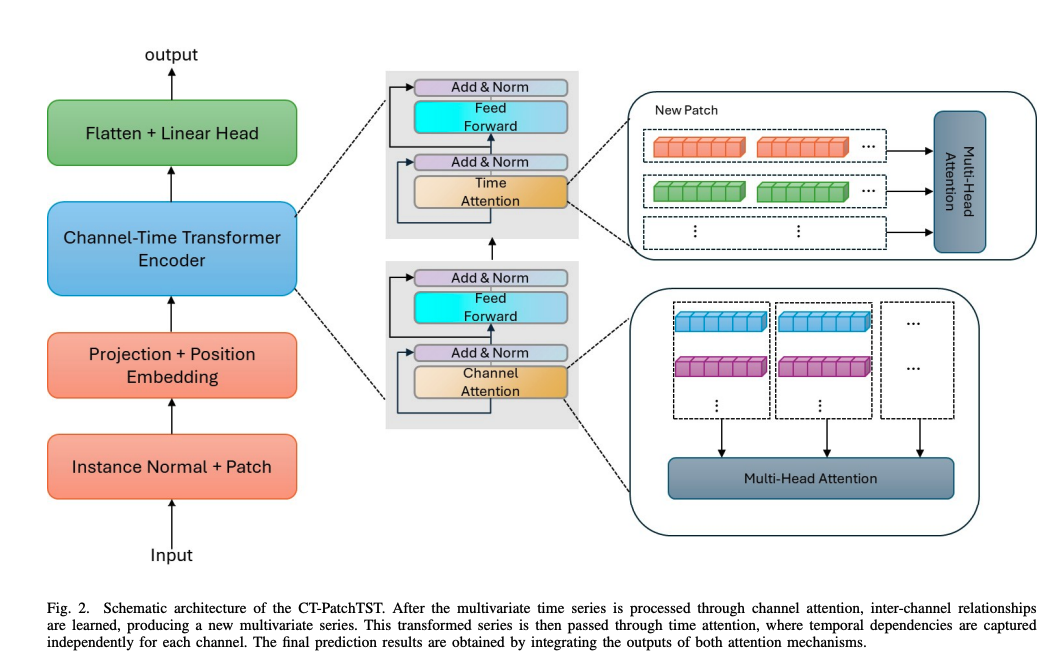

In [15]:
from IPython.display import Image
Image(
    filename=os.path.join(
        root_dir,
        "notebooks/Screenshot 2026-03-04 at 10.17.45 PM.png"
    )
)

In [16]:
"""
P = dimension after projection
N = total number of patches
M = number of multivariate features
"""
B, N, M, P = test_xb.shape

In [17]:
print(len(batch))
[print(x.shape) for x in batch]

print(self.xb.shape)
print(self.pred.shape)

2
torch.Size([64, 512, 7])
torch.Size([64, 96, 7])
torch.Size([64, 42, 7, 12])
torch.Size([64, 96, 7])


In [18]:
np.floor(
    (args.context_points - args.patch_len) / args.stride
) + 2

43.0

PatchTST
```python
class PatchTST:
    def __init__(self):
        self.backbone = PatchTSTEncoder(c_in, num_patch=num_patch, patch_len=patch_len, 
                                n_layers=n_layers, d_model=d_model, n_heads=n_heads, 
                                shared_embedding=shared_embedding, d_ff=d_ff,
                                attn_dropout=attn_dropout, dropout=dropout, act=act, 
                                res_attention=res_attention, pre_norm=pre_norm, store_attn=store_attn,
                                pe=pe, learn_pe=learn_pe, verbose=verbose, **kwargs)
        
    
    def forward(self, z):                             
        """
        z: tensor [bs x num_patch x n_vars x patch_len]
        """   
        z = self.backbone(z)                                                                # z: [bs x nvars x d_model x num_patch]
        z = self.head(z)                                                                    
        # z: [bs x target_dim x nvars] for prediction
        #    [bs x target_dim] for regression
        #    [bs x target_dim] for classification
        #    [bs x num_patch x n_vars x patch_len] for pretrain
        return z
```

PatchTSTEncoder

```python
class PatchTSTEncoder:

    def forward(self, x):
        bs, num_patch, n_vars, patch_len = x.shape
        # Input encoding
        if not self.shared_embedding:
            x_out = []
            for i in range(n_vars): 
                z = self.W_P[i](x[:,:,i,:])
                x_out.append(z)
            x = torch.stack(x_out, dim=2)
        else:
            x = self.W_P(x)                                                      # x: [bs x num_patch x nvars x d_model]
        x = x.transpose(1,2)                                                     # x: [bs x nvars x num_patch x d_model]        

        u = torch.reshape(x, (bs*n_vars, num_patch, self.d_model) )              # u: [bs * nvars x num_patch x d_model]
        u = self.dropout(u + self.W_pos)      
        # POSITIONAL Embedding parts

        # Encoder
        z = self.encoder(u)                                                      # z: [bs * nvars x num_patch x d_model]
        z = torch.reshape(z, (-1,n_vars, num_patch, self.d_model))               # z: [bs x nvars x num_patch x d_model]
        z = z.permute(0,1,3,2)                         
```

TSTEncoder
```python
class TSTEncoder:

    def __init__(self):
        self.layers = nn.ModuleList([
            TSTEncoderLayer(...)
        ])

    def forward(self, src: Tensor):
        output = src
        scores = None
        if self.res_attention:
            for mod in self.layers: output, scores = mod(output, prev=scores)
            return output
        else:
            for mod in self.layers: output = mod(output)
            return output
        
```


TSTEncoderLayer

```python
class TSTEncoderLayer:

    def forward(self, src: Tensor, prev: OPtional[TEnsor]):
        
        # Multi-Head attention sublayer
        if self.pre_norm:
            src = self.norm_attn(src)
        ## Multi-Head attention
        if self.res_attention:
            src2, attn, scores = self.self_attn(src, src, src, prev)
        else:
            src2, attn = self.self_attn(src, src, src)
        if self.store_attn:
            self.attn = attn
        ## Add & Norm
        src = src + self.dropout_attn(src2) # Add: residual connection with residual dropout
        if not self.pre_norm:
            src = self.norm_attn(src)

        # Feed-forward sublayer
        if self.pre_norm:
            src = self.norm_ffn(src)
        ## Position-wise Feed-Forward
        src2 = self.ff(src)
        ## Add & Norm
        src = src + self.dropout_ffn(src2) # Add: residual connection with residual dropout
        if not self.pre_norm:
            src = self.norm_ffn(src)

        if self.res_attention:
            return src, scores
        else:
            return src        

```

# Patch TST

In [19]:
# PatchTSTEncoder
x = test_xb
self = model.backbone

bs, num_patch, n_vars, patch_len = x.shape
print("Batch (B): ", bs)
print("Num Patch (N): ", num_patch)
print("Multivariate Features (M): ", n_vars)
print("Patch Length (P)", patch_len)

# let's assume projection is Identity. lambda x: x

# Input encoding
if not self.shared_embedding:
    x_out = []
    for i in range(n_vars): 
        z = self.W_P[i](x[:,:,i,:])
        x_out.append(z)
    x = torch.stack(x_out, dim=2)
else:
    x = self.W_P(x)                                                      # x: [bs x num_patch x nvars x d_model]

x = x.transpose(1,2)                                                     # x: [bs x nvars x num_patch x d_model]        

u = torch.reshape(x, (bs*n_vars, num_patch, self.d_model) )              # u: [bs * nvars x num_patch x d_model]

u = self.dropout(u + self.W_pos)      

print("original input shape: ", u.shape)
print("positional encoding shape: ", self.W_pos.shape)
"""
PatchTST positional encoding is (P, self.d_model)
CT PatchTST positional encoding is (P, N) - if I understand correctly
"""


# # Encoder
# z = self.encoder(u)                            

# TSTEncoder
src = u
output = src
scores = None

# res_attention = False in this config
# for mod in self.layers: output = mod(output)
# let's assume we only have one layer
self = model.backbone.encoder.layers[0]

print("TST Encoder Layer Input Shape: ", output.shape)

Batch (B):  64
Num Patch (N):  42
Multivariate Features (M):  7
Patch Length (P) 12
original input shape:  torch.Size([448, 42, 128])
positional encoding shape:  torch.Size([42, 128])
TST Encoder Layer Input Shape:  torch.Size([448, 42, 128])


In [20]:
# TSTEncoderLayer
src = output

# Multi-Head attention sublayer
if self.pre_norm:
    src = self.norm_attn(src)

## Multi-Head attention
print("res_attention: ", self.res_attention)
if self.res_attention:
    src2, attn, scores = self.self_attn(src, src, src, prev)
else:
    src2, attn = self.self_attn(src, src, src)


test_xb.shape

res_attention:  False


torch.Size([64, 42, 7, 12])

# CT Patch TST

In [23]:
# PatchTSTEncoder
x = test_xb
self = model.backbone

bs, num_patch, n_vars, patch_len = x.shape
print("Batch (B, bs): ", bs)
print("Num Patch (N, num_patch): ", num_patch)
print("Multivariate Features (M, num_vars): ", n_vars)
print("Projection (P, patch_len)", patch_len)

# let's assume projection is Identity. lambda x: x

# Input encoding
if not self.shared_embedding:
    x_out = []
    for i in range(n_vars): 
        z = self.W_P[i](x[:,:,i,:])
        x_out.append(z)
    x = torch.stack(x_out, dim=2)
else:
    x = self.W_P(x)                                                      
    # x: [bs x num_patch x nvars x d_model]

x = x.transpose(1,2)                                                     # x: [bs x nvars x num_patch x d_model]        

u = torch.reshape(x, (bs*n_vars, num_patch, self.d_model) )              # u: [bs * nvars x num_patch x d_model]
u = self.dropout(u + self.W_pos)                                         # u: [bs * nvars x num_patch x d_model]

Batch (B, bs):  64
Num Patch (N, num_patch):  42
Multivariate Features (M, num_vars):  7
Projection (P, patch_len) 12


In [33]:
u.shape

torch.Size([448, 42, 128])

In [31]:
d_model = self.d_model
src = u
src = torch.reshape(
    src, (bs, n_vars, num_patch, d_model)
)
src = src.transpose(1,2)     
src = torch.reshape(
    src, (bs*num_patch, n_vars, d_model)
)

In [32]:
src.shape

torch.Size([2688, 7, 128])

In [ ]:
# SCRATCH

In [116]:
from src.models.layers.pos_encoding import *
pe = "zeros" # default
learn_pe = True # default
num_patch = num_patch # 42 in this case
patch_len = patch_len # 12
d_model = 128  # 128 in this case

"""
def positional_encoding(pe, learn_pe, q_len, d_model):
    # Positional encoding
    if pe == None:
        W_pos = torch.empty((q_len, d_model)) # pe = None and learn_pe = False can be used to measure impact of pe
        nn.init.uniform_(W_pos, -0.02, 0.02)
        learn_pe = False
    elif pe == 'zero':
        W_pos = torch.empty((q_len, 1))
        nn.init.uniform_(W_pos, -0.02, 0.02)
"""

# patch tst
# positional_encoding(pe, learn_pe, num_patch, d_model)

# ct patch tst
W_pos_ct = positional_encoding(pe, learn_pe, patch_len, num_patch)
W_pos_ct.shape

torch.Size([12, 42])

res_attention:  False


torch.Size([64, 42, 7, 12])

# MultiHeadAttention

Standard Input is shape (L, N, E)
- L (Target Sequence Length)
- N (Batch Size)
- E (Embedidng Dimension)



64.0

Checking batch shape

```python
print(len(batch))
[print(x.shape) for x in batch]

print(self.xb.shape)
print(self.pred.shape)

# 2
# torch.Size([64, 512, 7])
# torch.Size([64, 96, 7])


# torch.Size([33, 42, 7, 12])
# torch.Size([33, 96, 7])
```

xb is our look back period (512), 64 is batch size, 7 is number of features

between input batch size should match. 